<a href="https://colab.research.google.com/github/Sebas-Atehortua/Integracion-de-Datos-y-Prospectiva/blob/main/Integraci%C3%B3n_DB_EPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integración de Datos y Análisis de Credibilidad - Caso Entidades Promotoras de Salud (EPS)**

El siguiente modelo tiene como objetivo integrar la información de pacientes de la sucursal de Sabaneta que está próxima a cerrar hacia las demás sucursales de la red prestadora de salud. Se trata de garantizar una reubicación estadísticamente consistente, que mitigue el impacto operativo y mantenga estable el perfil clínico de las sucursales que recibirán a estos pacientes.

Dado que la información de los pacientes varía entre las sucursales y la estructura poblacional de cada clínica es distinta, se emplea la **Teoría de la Credibilidad** para determinar el grado de afinidad o compatibilidad de la sucursal de Sabaneta con las demás sedes. Posteriormente, se utilizan métodos aleatorios (Valor de Pertenencia y Aceptación/Rechazo) para la asignación óptima de cada paciente.

Para seleccionar la variable de interés, se tuvo en cuenta las variables que logran replicarse en la base de datos:

*   **Índice de Masa Corporal** (BMI) como unidad física y fundamental para caracterizar a los pacientes propensos a sufrir de diabetes.
*   **Función de Pedrigrí de Diabetes** (DiabetesPedigreeFunction) como dato que refleja la herencia genética

Con ambas variables se podría construir un modelo apropiado, sin embargo, a diferencia de la función de pedrigrí, el BMI suele seguir una distribución de campana en la que la mayoría de los pacientes se sitúan en el centro, facilitando una media hipotética estable para la construcción de los métodos aleatorios que se van a emplear, por lo tanto se toma el **BMI** como variable de referencia para la integración.

Otra variable es Glucosa, sin embargo, esta al estar medida únicamente en 5 de las 6 sucursales y no en su totalidad esta variable alteraría el análisis y hará que los datos no se integren correctamente.

0. Se cargan las librerías de trabajo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Se define el formato y se ajustan los decimales
sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:.4f}'.format

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


1. Se montan los archivos de trabajo

**Nota**: Dado que el archivo tiene múltiples hojas y algunas difieren en columnas, cargaremos todas las hojas y extraeremos únicamente la variable de interés (BMI) para evitar conflictos.

In [ ]:
# Cargar base de datos unificada con múltiples hojas
db = '/content/drive/MyDrive/Integración de Datos/Parcial #1/3. Parcial - medical_attention_data.xlsx'
hojas = ['Bello', 'Envigado', 'Medellín', 'Itagui', 'Sabaneta', 'Caldas']
datos_sucursales = {}

var_ref = 'BMI'

# Extracción iterativa de la variable de referencia por sucursal

for hoja in ['Bello', 'Envigado', 'Medellín', 'Itagui', 'Sabaneta', 'Caldas']:
    df = pd.read_excel(db, sheet_name=hoja)
    datos_sucursales[hoja] = df[var_ref].dropna().values

print("=== Dimensiones de las bases de datos ===")
for nombre, datos in datos_sucursales.items():
    print(f"  {nombre}: {len(datos)} pacientes")

sabaneta_bmi = datos_sucursales['Sabaneta']

=== Dimensiones de las bases de datos ===
  Bello: 502 pacientes
  Envigado: 792 pacientes
  Medellín: 895 pacientes
  Itagui: 684 pacientes
  Sabaneta: 621 pacientes
  Caldas: 909 pacientes


1.1. Criterio de selección de la variable de referencia


===== CRITERIO DE SELECCIÓN – HOMOGENEIDAD ENTRE SUCURSALES =====
                          CV entre sedes
BMI                               0.0090
Age                               0.0093
BloodPressure                     0.0120
SkinThickness                     0.0140
DiabetesPedigreeFunction          0.0143
Insulin                           0.0252

>>> Variable seleccionada: BMI (CV = 0.009)


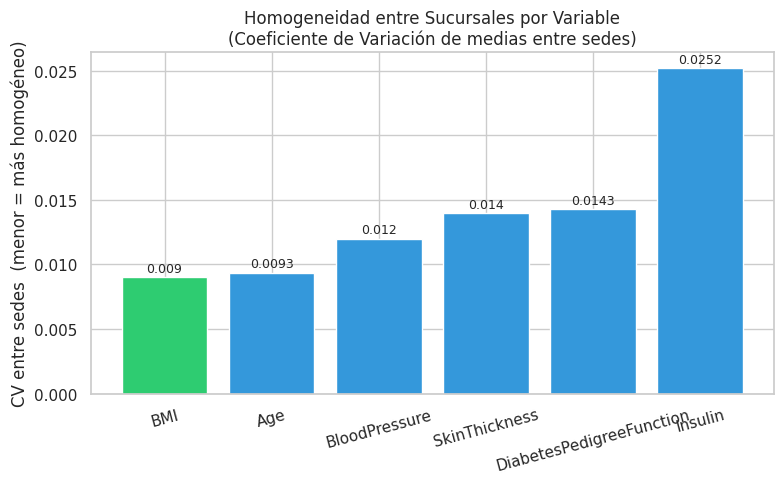

In [ ]:
vars_comunes   = ['BloodPressure', 'SkinThickness', 'Insulin',
                  'BMI', 'DiabetesPedigreeFunction', 'Age']
bd_map_completo = {h: pd.read_excel(db, sheet_name=h)
                   for h in datos_sucursales}

resumen_cv = {}
for var in vars_comunes:
    medias = [bd_map_completo[h][var].mean() for h in bd_map_completo]
    resumen_cv[var] = round(np.std(medias) / np.mean(medias), 6)

df_cv = pd.DataFrame.from_dict(resumen_cv, orient='index',
                                columns=['CV entre sedes']).sort_values('CV entre sedes')
print("\n===== CRITERIO DE SELECCIÓN – HOMOGENEIDAD ENTRE SUCURSALES =====")
print(df_cv.to_string())

variable_ref = df_cv['CV entre sedes'].idxmin()
print(f"\n>>> Variable seleccionada: {variable_ref} "
      f"(CV = {df_cv.loc[variable_ref, 'CV entre sedes']})")

plt.figure(figsize=(8, 5))
colores = ['#2ecc71' if v == variable_ref else '#3498db' for v in df_cv.index]
bars = plt.bar(df_cv.index, df_cv['CV entre sedes'],
               color=colores, edgecolor='white')
plt.title("Homogeneidad entre Sucursales por Variable\n"
          "(Coeficiente de Variación de medias entre sedes)")
plt.ylabel("CV entre sedes  (menor = más homogéneo)")
plt.xticks(rotation=15)
for bar, val in zip(bars, df_cv['CV entre sedes']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0002,
             f'{round(val, 4)}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Al presentar un menor coeficiente de variación, el IMC presenta una distribución más homogénea y consistente entre sucursales.

2. Se crea la función de caracterización de las variables

In [ ]:
def caracterizacion(X, nombre, plot=True):
    print(f"\n===== {nombre} =====")
    media      = round(np.mean(X), 2)
    varianza   = round(np.var(X), 2)
    desviacion = round(np.std(X), 2)
    asimetria  = round(skew(X), 2)
    curtosis_  = round(kurtosis(X), 2)

    print("N (pacientes) :", len(X))
    print("Media         :", media)
    print("Varianza      :", varianza)
    print("Desviación    :", desviacion)
    print("Asimetría     :", asimetria)
    print("Curtosis      :", curtosis_)

    if plot:
        plt.figure(figsize=(6, 4))
        sns.histplot(X, bins=15, kde=True, color='teal')
        plt.title(f"Distribución de {var_ref} – {nombre}")
        plt.xlabel(f"{var_ref} (kg/m²)")
        plt.ylabel("Frecuencia de ocurrencia")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return media, varianza, desviacion, asimetria, curtosis_

2.1. Se caracterizan las variables en medidas de tendencia central antes de la integración


===== Sabaneta (sucursal a cerrar) =====
N (pacientes) : 621
Media         : 32.99
Varianza      : 97.75
Desviación    : 9.89
Asimetría     : -0.02
Curtosis      : -1.15


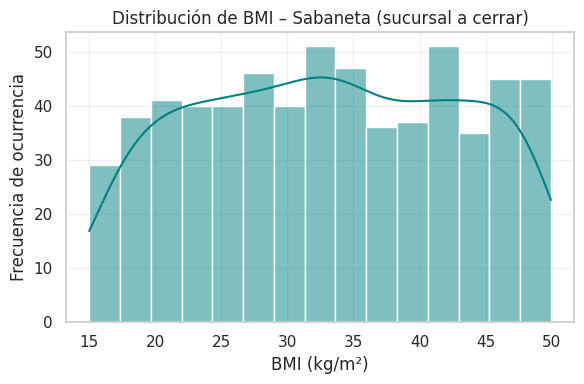


===== Bello =====
N (pacientes) : 502
Media         : 32.99
Varianza      : 97.45
Desviación    : 9.87
Asimetría     : -0.05
Curtosis      : -1.15


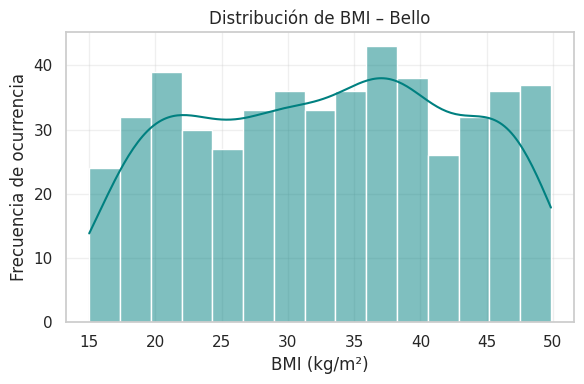


===== Envigado =====
N (pacientes) : 792
Media         : 32.55
Varianza      : 96.45
Desviación    : 9.82
Asimetría     : -0.03
Curtosis      : -1.12


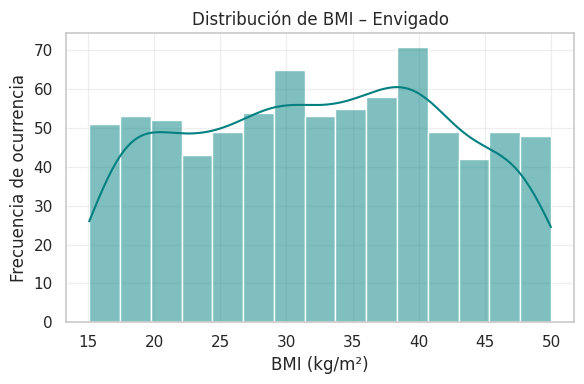


===== Medellín =====
N (pacientes) : 895
Media         : 32.88
Varianza      : 99.41
Desviación    : 9.97
Asimetría     : -0.07
Curtosis      : -1.17


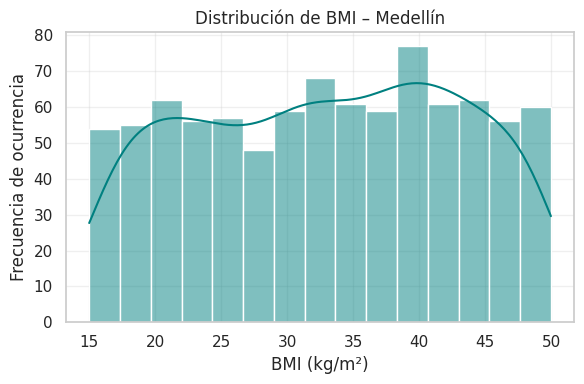


===== Itagui =====
N (pacientes) : 684
Media         : 32.24
Varianza      : 99.2
Desviación    : 9.96
Asimetría     : 0.03
Curtosis      : -1.16


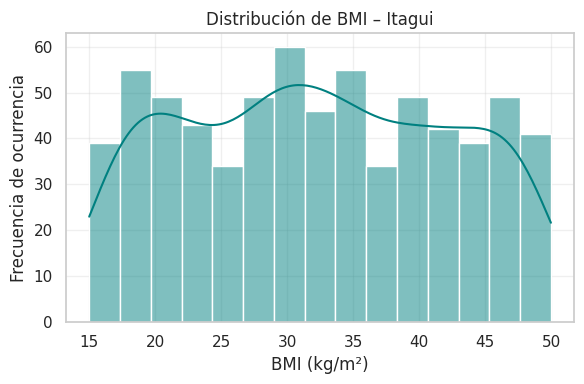


===== Caldas =====
N (pacientes) : 909
Media         : 33.06
Varianza      : 104.12
Desviación    : 10.2
Asimetría     : -0.11
Curtosis      : -1.19


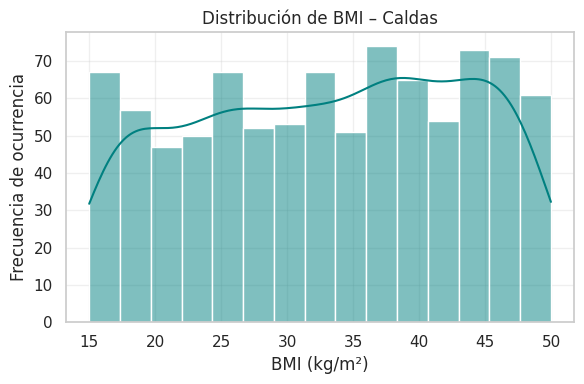

Gráfico que reune la distribución de todas las variables


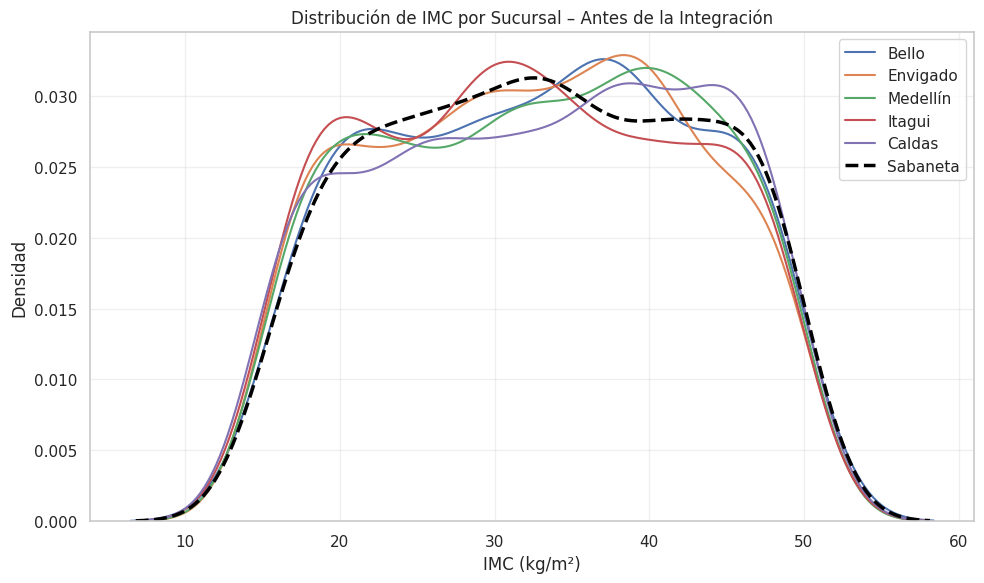

In [ ]:
# Sabaneta
u_sab, var_sab, sig_sab, ase_sab, kur_sab = caracterizacion(
    sabaneta_bmi, "Sabaneta (sucursal a cerrar)")
n_sab = len(sabaneta_bmi)

# Demás sucursales
stats = {}
for nombre, datos in datos_sucursales.items():
    if nombre == 'Sabaneta':
        continue
    u, var, sig, ase, kur = caracterizacion(datos, nombre)
    stats[nombre] = {'u': u, 'var': var, 'sig': sig,
                     'ase': ase, 'kur': kur,
                     'n': len(datos), 'X': datos}

# Visualización comparativa
plt.figure(figsize=(10, 6))
for nombre, s in stats.items():
    sns.kdeplot(s['X'], label=nombre)
sns.kdeplot(sabaneta_bmi, label='Sabaneta', linewidth=2.5,
            linestyle='--', color='black')

print("Gráfico que reune la distribución de todas las variables")


plt.title("Distribución de IMC por Sucursal – Antes de la Integración")
plt.xlabel("IMC (kg/m²)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Como se observa en la salida del modelo, la variable BMI en la sucursal de Sabaneta presenta una media de 32.99, lo que sitúa al paciente promedio en un rango de obesidad grado I. La desviación estándar de 9.89 sugiere una dispersión moderada, permitiendo que el modelo capture una amplia gama de perfiles clínicos.

3. **Se aplica la Teoría de la Credibilidad**

Se calcula el factor de credibiidad para cada una de las sucursales receptoras. Recordemos que un factor de credibilidad Z cercano a 1 estaría indicando alta afinidad con Sabaneta, mientras que Z cercano a 0 indica baja compatibilidad.


  --- Sabaneta vs Bello ---
  K : 976354.3891  |  Z : 0.0006  →  0.06%

  --- Sabaneta vs Envigado ---
  K : 2034.7331  |  Z : 0.2338  →  23.38%

  --- Sabaneta vs Medellín ---
  K : 33747.0526  |  Z : 0.0181  →  1.81%

  --- Sabaneta vs Itagui ---
  K : 702.3686  |  Z : 0.4693  →  46.93%

  --- Sabaneta vs Caldas ---
  K : 85911.1556  |  Z : 0.0072  →  0.72%

===== RESUMEN DE CREDIBILIDADES =====
Sucursal  Credibilidad_Z     Z%  Parametro_K
  Itagui          0.4693 46.93%     702.3686
Envigado          0.2338 23.38%    2034.7331
Medellín          0.0181  1.81%   33747.0526
  Caldas          0.0072  0.72%   85911.1556
   Bello          0.0006  0.06%  976354.3891

>>> Sucursal con mayor afinidad a Sabaneta: Itagui (Z = 46.93%)


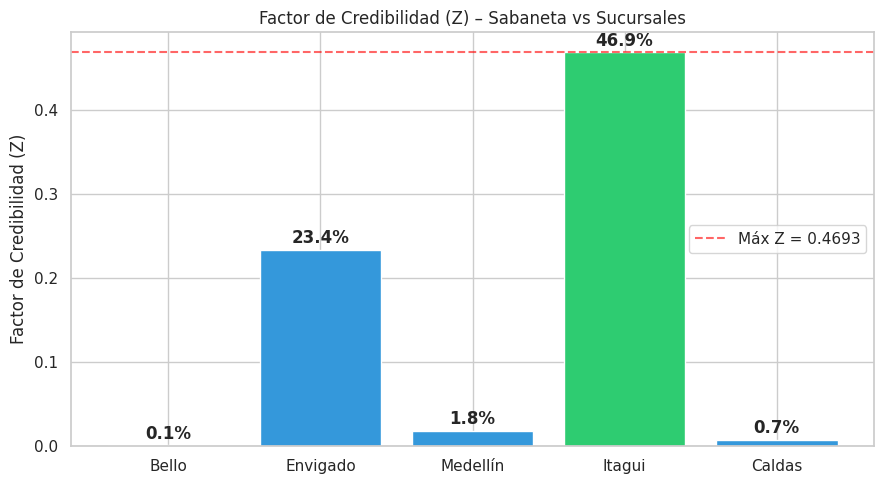

In [ ]:
credibilidades = {}
afinidad_resultados = []

for nombre, s in stats.items():

    N_can = s['n']

    # 1. Media hipotética combinada
    uhat = (n_sab * u_sab + N_can * s['u']) / (n_sab + N_can)

    # 2. EPV
    EPV  = (n_sab * sig_sab**2 + N_can * s['sig']**2) / (n_sab + N_can)

    # 3. VHM
    VHM  = ((n_sab * u_sab**2 + N_can * s['u']**2) / (n_sab + N_can)) - uhat**2
    if VHM <= 0:
        VHM = 0.0001

    # 4. K y Z
    K = EPV / VHM
    Z = n_sab / (n_sab + K)

    credibilidades[nombre] = {'K': K, 'Z': Z}
    afinidad_resultados.append({
        'Sucursal'      : nombre,
        'Credibilidad_Z': round(Z, 4),
        'Z%'            : f"{round(Z*100,2)}%",
        'Parametro_K'   : round(K, 4)
    })

    print(f"\n  --- Sabaneta vs {nombre} ---")
    print(f"  K : {round(K,4)}  |  Z : {round(Z,4)}  →  {round(Z*100,2)}%")

df_afinidad = pd.DataFrame(afinidad_resultados).sort_values(
    by='Credibilidad_Z', ascending=False)
print("\n===== RESUMEN DE CREDIBILIDADES =====")
print(df_afinidad.to_string(index=False))

# Sucursal más afín
mejor_sucursal = df_afinidad.iloc[0]['Sucursal']
Z_mejor        = df_afinidad.iloc[0]['Credibilidad_Z']
print(f"\n>>> Sucursal con mayor afinidad a Sabaneta: {mejor_sucursal} "
      f"(Z = {round(Z_mejor*100,2)}%)")


plt.figure(figsize=(9, 5))
nombres_plot = list(credibilidades.keys())
zs_plot      = [credibilidades[n]['Z'] for n in nombres_plot]
colores_plot = ['#2ecc71' if n == mejor_sucursal else '#3498db' for n in nombres_plot]
bars = plt.bar(nombres_plot, zs_plot, color=colores_plot, edgecolor='white')
plt.axhline(y=max(zs_plot), linestyle='--', color='red',
            alpha=0.6, label=f'Máx Z = {round(max(zs_plot),4)}')
plt.title("Factor de Credibilidad (Z) – Sabaneta vs Sucursales")
plt.ylabel("Factor de Credibilidad (Z)")
for bar, z in zip(bars, zs_plot):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{round(z*100,1)}%', ha='center', va='bottom', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


La aplicación del modelo de credibilidad nos indica que la sucursal
Itagüí presenta la mayor afinidad estadística con Sabaneta
(Z = 46.93%), lo que significa que la distribución del IMC
en sus pacientes es la más compatible con la de la sucursal a cerrar.

En consecuencia, Itagüí es la sede receptora prioritaria para
la reubicación de pacientes, mientras que las demás sucursales absorberán
pacientes en proporción a su respectivo factor de credibilidad.


4. **Reubicación mediante el Método del Valor de Pertenencia**

El Método del Valor de Pertenencia asigna cada paciente de Sabaneta a la sucursal cuya distribución de IMC sea más similar a su valor individual.

Para cada paciente de Sabaneta se calcula la función de pertenencia
respecto a cada sucursal receptora:

  VP = exp(-0.5 * ((μ_sucursal - BMI_paciente) / σ_sucursal)²)

Si VP > 0.9, el paciente es estadísticamente compatible con esa sucursal
y se integra a su base de datos.
El paciente queda asignado a la sucursal con menor distancia, es decir,
aquella a la que estadísticamente "pertenece" más.

In [ ]:
UMBRAL = 0.9

LDA_int_vp = {n: np.copy(s['X']) for n, s in stats_sucursales.items()}
conteo_vp  = {n: 0 for n in stats_sucursales}
no_asig_vp = 0

print("\n" + "="*60)
print("  MÉTODO DEL VALOR DE PERTENENCIA")
print("="*60)

for paciente_bmi in sabaneta_bmi:

    # VP del paciente respecto a cada sucursal
    vps = {
        n: np.exp(-0.5 * ((s['u'] - paciente_bmi) / s['sig']) ** 2)
        for n, s in stats_sucursales.items()
    }

    # Solo sucursales que superan el umbral
    candidatas = {n: vp for n, vp in vps.items() if vp > UMBRAL}

    if candidatas:
        mejor = max(candidatas, key=candidatas.get)
        conteo_vp[mejor] += 1
        LDA_int_vp[mejor] = np.append(LDA_int_vp[mejor], paciente_bmi)
    else:
        no_asig_vp += 1

print("\n===== RESUMEN – VALOR DE PERTENENCIA =====")
for nombre, n in conteo_vp.items():
    print(f"  {nombre}: {n} pacientes integrados")
print(f"  Sin asignar (VP < {UMBRAL} en todas): {no_asig_vp}")
print(f"  Total verificación: {sum(conteo_vp.values()) + no_asig_vp} / {n_sab}")


# ===========================================================================
# 4.1. Validación estadística – Antes vs Después (Valor de Pertenencia)
# ===========================================================================

print("\n===== VALIDACIÓN ESTADÍSTICA – VALOR DE PERTENENCIA =====")

for nombre, s in stats_sucursales.items():

    u_i, _, sig_i, ase_i, kur_i = caracterizacion(
        LDA_int_vp[nombre], f"{nombre} – Integrado (VP)", plot=False)

    disc_u   = np.abs((s['u']   - u_i)   / s['u'])   * 100
    disc_sig = np.abs((s['sig'] - sig_i) / s['sig']) * 100
    disc_ase = np.abs((s['ase'] - ase_i) / s['ase']) * 100 if s['ase'] != 0 else 0
    disc_kur = np.abs((s['kur'] - kur_i) / s['kur']) * 100 if s['kur'] != 0 else 0

    print(f"\n  === {nombre} ===")
    print(f"  {'Métrica':<12} {'Antes':>10} {'Después':>10} {'Discrepancia':>14}")
    print(f"  {'-'*48}")
    print(f"  {'Media':<12} {round(s['u'],4):>10} {round(u_i,4):>10} {round(disc_u,2):>13}%")
    print(f"  {'Sigma':<12} {round(s['sig'],4):>10} {round(sig_i,4):>10} {round(disc_sig,2):>13}%")
    print(f"  {'Asimetría':<12} {round(s['ase'],4):>10} {round(ase_i,4):>10} {round(disc_ase,2):>13}%")
    print(f"  {'Curtosis':<12} {round(s['kur'],4):>10} {round(kur_i,4):>10} {round(disc_kur,2):>13}%")




  MÉTODO DEL VALOR DE PERTENENCIA

===== RESUMEN – VALOR DE PERTENENCIA =====
  Bello: 3 pacientes integrados
  Envigado: 11 pacientes integrados
  Medellín: 3 pacientes integrados
  Itagui: 87 pacientes integrados
  Caldas: 88 pacientes integrados
  Sin asignar (VP < 0.9 en todas): 429
  Total verificación: 621 / 621

===== VALIDACIÓN ESTADÍSTICA – VALOR DE PERTENENCIA =====

===== Bello – Integrado (VP) =====
N (pacientes) : 505
Media         : 32.99
Varianza      : 96.88
Desviación    : 9.84
Asimetría     : -0.05
Curtosis      : -1.14

  === Bello ===
  Métrica           Antes    Después   Discrepancia
  ------------------------------------------------
  Media             32.99      32.99           0.0%
  Sigma              9.87       9.84           0.3%
  Asimetría         -0.05      -0.05           0.0%
  Curtosis          -1.15      -1.14          0.87%

===== Envigado – Integrado (VP) =====
N (pacientes) : 803
Media         : 32.55
Varianza      : 95.13
Desviación    : 9.75
Asi

5. **Aceptación y Rechazo – Integración de pacientes de Sabaneta**

Se evalúan las sucursales en orden descendente de credibilidad (Z).
Para cada sucursal candidata se genera U ~ Unif(0,1). El paciente es
aceptado si VP > UMBRAL AND VP > U. La primera sucursal que lo acepta
lo integra y se detiene la evaluación (break). Si ninguna acepta al
paciente, queda sin asignar.

In [ ]:
# Establecemos una semilla para evitar la variabilidad de los datos
np.random.seed(42)

LDA_int_ar = {n: np.copy(s['X']) for n, s in stats_sucursales.items()}
conteo_ar  = {n: 0 for n in stats_sucursales}
no_asig_ar = 0

orden = sorted(stats_sucursales.keys(),
               key=lambda n: credibilidades[n]['Z'], reverse=True)

print("\n" + "="*60)
print("  MÉTODO DE ACEPTACIÓN Y RECHAZO")
print("="*60)
print(f"\n  Orden de evaluación (Z descendente): {orden}")

for paciente_bmi in sabaneta_bmi:

    asignado = None

    for nombre in orden:
        s  = stats_sucursales[nombre]
        VP = np.exp(-0.5 * ((s['u'] - paciente_bmi) / s['sig']) ** 2)
        U  = np.random.uniform(0, 1)

        if VP > UMBRAL and VP > U:
            asignado = nombre
            conteo_ar[nombre] += 1
            LDA_int_ar[nombre] = np.append(LDA_int_ar[nombre], paciente_bmi)
            break

    if asignado is None:
        no_asig_ar += 1

print("\n===== RESUMEN – ACEPTACIÓN Y RECHAZO =====")
for nombre, n in conteo_ar.items():
    print(f"  {nombre}: {n} pacientes integrados")
print(f"  Sin asignar (rechazados en todas): {no_asig_ar}")
print(f"  Total verificación: {sum(conteo_ar.values()) + no_asig_ar} / {n_sab}")


# ===========================================================================
# 5.1. Validación estadística – Antes vs Después (Aceptación y Rechazo)
# ===========================================================================

print("\n===== VALIDACIÓN ESTADÍSTICA – ACEPTACIÓN Y RECHAZO =====")

for nombre, s in stats_sucursales.items():

    u_i, _, sig_i, ase_i, kur_i = caracterizacion(
        LDA_int_ar[nombre], f"{nombre} – Integrado (A/R)", plot=False)

    disc_u   = np.abs((s['u']   - u_i)   / s['u'])   * 100
    disc_sig = np.abs((s['sig'] - sig_i) / s['sig']) * 100
    disc_ase = np.abs((s['ase'] - ase_i) / s['ase']) * 100 if s['ase'] != 0 else 0
    disc_kur = np.abs((s['kur'] - kur_i) / s['kur']) * 100 if s['kur'] != 0 else 0

    print(f"\n  === {nombre} ===")
    print(f"  {'Métrica':<12} {'Antes':>10} {'Después':>10} {'Discrepancia':>14}")
    print(f"  {'-'*48}")
    print(f"  {'Media':<12} {round(s['u'],4):>10} {round(u_i,4):>10} {round(disc_u,2):>13}%")
    print(f"  {'Sigma':<12} {round(s['sig'],4):>10} {round(sig_i,4):>10} {round(disc_sig,2):>13}%")
    print(f"  {'Asimetría':<12} {round(s['ase'],4):>10} {round(ase_i,4):>10} {round(disc_ase,2):>13}%")
    print(f"  {'Curtosis':<12} {round(s['kur'],4):>10} {round(kur_i,4):>10} {round(disc_kur,2):>13}%")




  MÉTODO DE ACEPTACIÓN Y RECHAZO

  Orden de evaluación (Z descendente): ['Itagui', 'Envigado', 'Medellín', 'Caldas', 'Bello']

===== RESUMEN – ACEPTACIÓN Y RECHAZO =====
  Bello: 0 pacientes integrados
  Envigado: 7 pacientes integrados
  Medellín: 12 pacientes integrados
  Itagui: 171 pacientes integrados
  Caldas: 1 pacientes integrados
  Sin asignar (rechazados en todas): 430
  Total verificación: 621 / 621

===== VALIDACIÓN ESTADÍSTICA – ACEPTACIÓN Y RECHAZO =====

===== Bello – Integrado (A/R) =====
N (pacientes) : 502
Media         : 32.99
Varianza      : 97.45
Desviación    : 9.87
Asimetría     : -0.05
Curtosis      : -1.15

  === Bello ===
  Métrica           Antes    Después   Discrepancia
  ------------------------------------------------
  Media             32.99      32.99           0.0%
  Sigma              9.87       9.87           0.0%
  Asimetría         -0.05      -0.05           0.0%
  Curtosis          -1.15      -1.15           0.0%

===== Envigado – Integrado (A/

***Volumen de la integración***

Itagui absorbió la gran mayoría (171 de 191 pacientes integrados), lo cual es consistente con su mayor credibilidad Z = 46.99%. El orden de evaluación le da prioridad y su VP es sistemáticamente el más alto por tener la media más cercana al centro de la distribución de Sabaneta. Bello no recibió ningún paciente porque al ser evaluado de último, los pocos pacientes que llegaban hasta él ya habían sido aceptados por sucursales anteriores.


5.2. Comparación entre los métodos



  COMPARACIÓN ENTRE MÉTODOS DE INTEGRACIÓN

  Sucursal       Val. Pertenencia   Acep./Rechazo
  -----------------------------------------------
  Bello                         3               0
  Envigado                     11               7
  Medellín                      3              12
  Itagui                       87             171
  Caldas                       88               1
  Sin asignar                 429             430


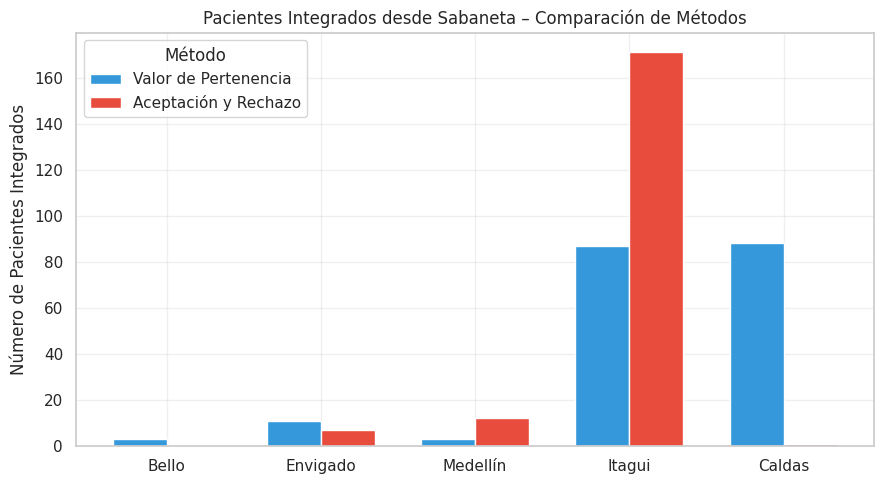

In [ ]:
print("\n" + "="*60)
print("  COMPARACIÓN ENTRE MÉTODOS DE INTEGRACIÓN")
print("="*60)
print(f"\n  {'Sucursal':<12} {'Val. Pertenencia':>18} {'Acep./Rechazo':>15}")
print(f"  {'-'*47}")
for nombre in stats_sucursales:
    print(f"  {nombre:<12} {conteo_vp[nombre]:>18} {conteo_ar[nombre]:>15}")
print(f"  {'Sin asignar':<12} {no_asig_vp:>18} {no_asig_ar:>15}")

plt.figure(figsize=(9, 5))
nombres_suc = list(stats_sucursales.keys())
x     = np.arange(len(nombres_suc))
ancho = 0.35
plt.bar(x - ancho/2, [conteo_vp[n] for n in nombres_suc],
        ancho, label='Valor de Pertenencia', color='#3498db', edgecolor='white')
plt.bar(x + ancho/2, [conteo_ar[n] for n in nombres_suc],
        ancho, label='Aceptación y Rechazo',  color='#e74c3c', edgecolor='white')
plt.xticks(x, nombres_suc)
plt.title("Pacientes Integrados desde Sabaneta – Comparación de Métodos")
plt.ylabel("Número de Pacientes Integrados")
plt.legend(title="Método")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusiones**

La integración de datos mediante Teoría de Credibilidad y Métodos de Aceptación y Rechazo permitió determinar que Itagui es la sucursal más afín a Sabaneta y la sede receptora natural de la mayoría de sus pacientes. En ambos métodos la media presentó discrepancias inferiores al 0.2% en todas las sucursales, confirmando que los pacientes integrados son estadísticamente compatibles con las poblaciones receptoras. Si bien difieren en la distribución final: el Valor de Pertenencia reparte más equitativamente entre Itagui y Caldas, mientras que Aceptación y Rechazo concentra la reubicación respetando la jerarquía de credibilidad. El alto volumen de pacientes no asignados (≈69%) refleja la rigurosidad del umbral VP > 0.9, que garantiza que solo se integren pacientes con alta compatibilidad estadística, preservando la integridad clínica y poblacional de cada sucursal receptora. Para absorber una mayor proporción de pacientes de Sabaneta, la entidad bajar el umbral a 0.7 o 0.8, manteniendo un criterio de integración estadísticamente defendible.